# Final Notebook
## AI Dependency, Career Anxiety, and Student Burnout Analysis

Student: Hasrat Buttar\
Student Number: 301554205\
Course: IAT 461

### Import Libraries

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

### Load Dataset

In [90]:
df = pd.read_csv("ai_dependency_career_anxiety_students.csv")

### Preview Dataset

In [91]:
df.head()

,student_id,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
0,STU_00001,25,Male,B.Tech/B.E.,Engineering (Non-CS),3,Tier 3,Rural,0.3,Perplexity,...,3.5,8.7,2,1.5,8.5,1,3,6,0.0,9.09
1,STU_00002,20,Female,B.Tech/B.E.,Engineering (Non-CS),4,Tier 3,Urban,1.9,ChatGPT,...,2.4,8.2,3,4.2,8.3,4,5,3,0.0,6.03
2,STU_00003,25,Female,MBA,CS/IT,1,Tier 3,Urban,3.6,Gemini,...,2.3,16.4,1,2.3,7.0,5,9,3,1.0,6.68
3,STU_00004,23,Male,B.Tech/B.E.,CS/IT,1,Tier 1,Urban,4.1,GitHub Copilot,...,7.7,15.0,3,2.6,7.2,6,6,6,0.0,7.71
4,STU_00005,22,Female,MBA,CS/IT,1,Tier 1,Urban,3.4,ChatGPT,...,2.4,1.1,2,1.9,8.0,3,5,4,0.0,4.64


## Dataset Information

In [92]:
df.shape

(15000, 30)

In [93]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       15000 non-null  str    
 1   age                              15000 non-null  int64  
 2   gender                           15000 non-null  str    
 3   degree_type                      15000 non-null  str    
 4   stream                           15000 non-null  str    
 5   year_of_study                    15000 non-null  int64  
 6   college_tier                     15000 non-null  str    
 7   urban_or_rural                   15000 non-null  str    
 8   daily_ai_tool_usage_hrs          15000 non-null  float64
 9   primary_ai_tools_used            11785 non-null  str    
 10  uses_ai_for_assignments          15000 non-null  str    
 11  ai_replaces_own_thinking_score   15000 non-null  int64  
 12  ai_dependency_score          

In [94]:
df.describe()

,age,year_of_study,daily_ai_tool_usage_hrs,ai_replaces_own_thinking_score,ai_dependency_score,placement_anxiety_score,fear_of_job_loss_to_ai,career_clarity_score,internship_experience,weekly_job_application_count,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,15000.000000,14767.000000,15000.0000,14790.000000,14797.000000,15000.000000,15000.000000,15000.000000,14780.000000,15000.000000
mean,21.384533,2.100067,2.013893,2.987733,4.539133,5.913933,3.551200,5.025333,1.718333,10.636133,...,2.730660,6.304612,2.0326,3.006437,6.993364,4.771133,5.472600,4.319733,0.285792,5.998019
std,2.005626,0.987650,1.735977,1.311932,2.315115,2.548207,1.180397,2.200806,1.069583,6.402411,...,1.801026,5.553880,1.8095,1.649033,1.004809,1.778210,2.068317,2.151266,0.451806,1.593982
min,18.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.0000,0.000000,4.000000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,20.000000,1.000000,0.400000,2.000000,3.000000,4.000000,3.000000,3.000000,1.000000,6.000000,...,1.300000,1.000000,1.0000,1.800000,6.300000,4.000000,4.000000,3.000000,0.000000,4.900000
50%,21.000000,2.000000,1.800000,3.000000,4.000000,6.000000,4.000000,5.000000,2.000000,10.000000,...,2.600000,5.500000,2.0000,3.000000,7.000000,5.000000,5.000000,4.000000,0.000000,6.000000
75%,22.000000,3.000000,3.200000,4.000000,6.000000,8.000000,5.000000,6.000000,2.000000,15.000000,...,4.000000,10.100000,3.0000,4.100000,7.700000,6.000000,7.000000,6.000000,1.000000,7.120000
max,28.000000,4.000000,8.000000,5.000000,10.000000,10.000000,5.000000,10.000000,4.000000,35.000000,...,10.300000,31.000000,10.0000,8.000000,10.000000,10.000000,10.000000,10.000000,1.000000,10.000000


## Check for Missing Values

In [95]:
df.isnull().sum().sort_values(ascending=False)

primary_ai_tools_used              3215
self_learning_hours_per_week        233
seeks_career_counseling             220
social_media_hrs_per_day            210
sleep_hours                         203
student_id                            0
internship_experience                 0
motivation_score                      0
burnout_score                         0
stress_level                          0
skill_development_courses_taken       0
daily_study_hours                     0
interview_anxiety_score               0
resume_confidence_score               0
weekly_job_application_count          0
career_clarity_score                  0
age                                   0
fear_of_job_loss_to_ai                0
placement_anxiety_score               0
ai_dependency_score                   0
ai_replaces_own_thinking_score        0
uses_ai_for_assignments               0
daily_ai_tool_usage_hrs               0
urban_or_rural                        0
college_tier                          0


### Dealing with primary_ai_tools_used Missing Values

In [96]:
df["primary_ai_tools_used"] = df["primary_ai_tools_used"].fillna("Unknown")

I decided to replace the missing values with "Unknown" because nearly 20% of the dataset has this field as missing, hence, I do not think it is worth deleting. Additionally, this field is not critical to answering the clients' primary questions.

### Dealing with self_learning_hours_per_week Missing Values

In [97]:
df = df[df["self_learning_hours_per_week"].notna()].copy()

I decided to drop records where this field is missing because this field is pretty subjective and replacing it with the mean could distort the data. This is a field that I will be utilizing to answer my client's questions hence I wanted to keep it as accurate and genuine as possible. Additionally, 233 records is not an overly significant portion of the otherwise 15000 records.

### Dealing with seeks_career_counseling Missing Values

In [98]:
df["seeks_career_counseling"] = (df["seeks_career_counseling"].fillna(df["seeks_career_counseling"].mode()[0]))

I decided to impute with the mode because this field does not play a critical role in addressing my client's questions and dropping 220 records seemed unnecessary. Moreover, because it is a yes or no field, I decided to impute with the mode as median is not logical.

### Dealing with social_media_hrs_per_day Missing Values

In [99]:
df["social_media_hrs_per_day"] = (df["social_media_hrs_per_day"].fillna(df["social_media_hrs_per_day"].median()))

I decided to impute with the median because this field also does not play a critical role in addressing my client's question and it is unneccessary to drop 210 records that could otherwise provide fruitful information. 

### Dealing with sleep_hours

In [100]:
df = df[df["sleep_hours"].notna()].copy()

I decided to drop records that did not have this field filled because I anticipate utilizing this field to gather a greater understanding of user behaviour and want to see how it links specifically to a student's stress levels and ai use. Given that there are only 203 records with a missing value for this field, I am willing to make the sacrifice to ensure my analysis is more accurate and less distorted or skewed.

### Double Check no more Missing Values

In [101]:
df.isnull().sum().sort_values(ascending=False)

student_id                         0
age                                0
seeks_career_counseling            0
motivation_score                   0
burnout_score                      0
stress_level                       0
sleep_hours                        0
social_media_hrs_per_day           0
skill_development_courses_taken    0
self_learning_hours_per_week       0
daily_study_hours                  0
interview_anxiety_score            0
resume_confidence_score            0
weekly_job_application_count       0
internship_experience              0
career_clarity_score               0
fear_of_job_loss_to_ai             0
placement_anxiety_score            0
ai_dependency_score                0
ai_replaces_own_thinking_score     0
uses_ai_for_assignments            0
primary_ai_tools_used              0
daily_ai_tool_usage_hrs            0
urban_or_rural                     0
college_tier                       0
year_of_study                      0
stream                             0
d

There are now no missing values.

### Checking Shape

In [102]:
df.shape

(14565, 30)

After dealing with missing values, I have dropped 435 records, which is not a significant loss and equates to 2.9% of the initial data.

## Check for Outliers

In [103]:
df.describe()

,age,year_of_study,daily_ai_tool_usage_hrs,ai_replaces_own_thinking_score,ai_dependency_score,placement_anxiety_score,fear_of_job_loss_to_ai,career_clarity_score,internship_experience,weekly_job_application_count,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
count,14565.000000,14565.000000,14565.000000,14565.00000,14565.000000,14565.000000,14565.000000,14565.000000,14565.000000,14565.000000,...,14565.000000,14565.000000,14565.000000,14565.000000,14565.000000,14565.000000,14565.000000,14565.000000,14565.000000,14565.000000
mean,21.380227,2.100790,2.017020,2.99080,4.542945,5.916032,3.551459,5.024579,1.716718,10.646893,...,2.726866,6.304813,2.032475,3.006941,6.992667,4.770203,5.474150,4.319670,0.281291,5.997148
std,2.006449,0.987426,1.738136,1.31072,2.315247,2.548571,1.180633,2.200959,1.069386,6.406571,...,1.800614,5.553451,1.810010,1.639221,1.005107,1.777245,2.067548,2.150535,0.449644,1.594800
min,18.000000,1.000000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,20.000000,1.000000,0.400000,2.00000,3.000000,4.000000,3.000000,3.000000,1.000000,6.000000,...,1.300000,1.000000,1.000000,1.900000,6.300000,4.000000,4.000000,3.000000,0.000000,4.900000
50%,21.000000,2.000000,1.800000,3.00000,4.000000,6.000000,4.000000,5.000000,2.000000,10.000000,...,2.600000,5.500000,2.000000,3.000000,7.000000,5.000000,5.000000,4.000000,0.000000,5.990000
75%,22.000000,3.000000,3.200000,4.00000,6.000000,8.000000,5.000000,6.000000,2.000000,15.000000,...,4.000000,10.100000,3.000000,4.100000,7.700000,6.000000,7.000000,6.000000,1.000000,7.120000
max,28.000000,4.000000,8.000000,5.00000,10.000000,10.000000,5.000000,10.000000,4.000000,35.000000,...,10.300000,31.000000,10.000000,8.000000,10.000000,10.000000,10.000000,10.000000,1.000000,10.000000


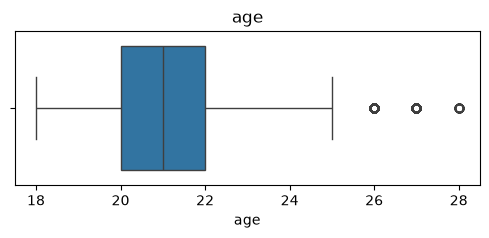

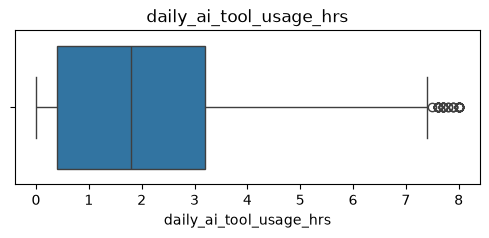

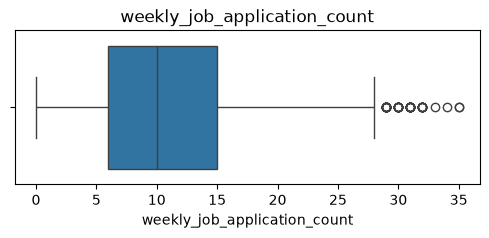

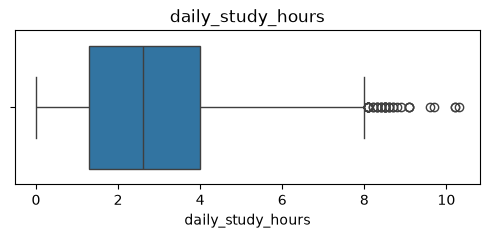

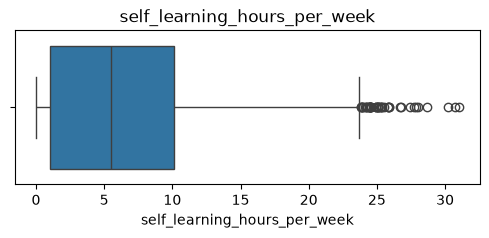

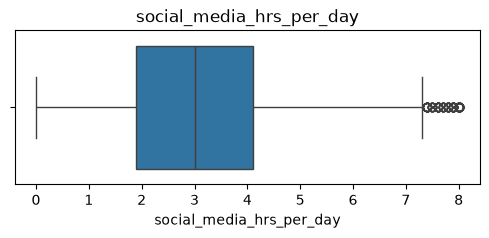

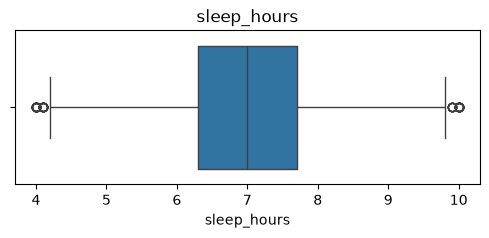

In [104]:
continuous_cols = [
    "age",
    "daily_ai_tool_usage_hrs",
    "weekly_job_application_count",
    "daily_study_hours",
    "self_learning_hours_per_week",
    "social_media_hrs_per_day",
    "sleep_hours"
]

for col in continuous_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

From these boxplots I do not see any point for concern.

Age: Although there are a few students aged 26-28, it is still realistic. These could be mature undergraduate students, graduate students, or students returning to school.

Daily AI Tool Usage: Numerous students use AI 7.5-8 hrs a day. This raises a bit of suspicion as it is high, however, it is justifiable as these could be students with more demanding majors using it to write code, reports, study, or even preparing for interviews.

Weekly Job Application Count: There are some students applying to 30-35 jobs a week. This is not concerning as students searching for jobs often submit multiple applications per day.

Daily Study Hours: Some students study 8-10 hours a day. This is high but plausible especially considering the demandng nature of some majors, exams, and projects. I am also curious whether lecture and lab times are cosnidered in this daily average. If so, this number would also be considered much more reasonable.

Self Learning Hours per Week: There are some students that self learn upwards of 30 hours each week. This is approximately 4-4.5 hours per day which is entirely possible for motivated students. Additionally, since one of my research questions is about highly-motivated students, it is counterintuitive to remove or impute these values.

Social Media Hours: Some students spend 7-8 hours on social media apps. This is high but not of concern, as this is a realistic occurence especially in a "doomscrolling" epidemic.

Sleep Hours: Some students sleep 4 hours. This is not concerning especially since these students may be the same ones that have high daily study hour numbers, social media hours, or self learning hours. It just implies sleep deprivation. On the other hand, there are students that sleep 10 hours. This is also plausible due to individual differences and different needs.

## Check for Duplicate Records

In [105]:
df.duplicated().sum()

np.int64(0)

There are no duplicate records.

## Closer Look at Variables

In [106]:
df.columns

Index(['student_id', 'age', 'gender', 'degree_type', 'stream', 'year_of_study',
       'college_tier', 'urban_or_rural', 'daily_ai_tool_usage_hrs',
       'primary_ai_tools_used', 'uses_ai_for_assignments',
       'ai_replaces_own_thinking_score', 'ai_dependency_score',
       'placement_anxiety_score', 'fear_of_job_loss_to_ai',
       'career_clarity_score', 'internship_experience',
       'weekly_job_application_count', 'resume_confidence_score',
       'interview_anxiety_score', 'daily_study_hours',
       'self_learning_hours_per_week', 'skill_development_courses_taken',
       'social_media_hrs_per_day', 'sleep_hours', 'stress_level',
       'burnout_score', 'motivation_score', 'seeks_career_counseling',
       'overall_career_readiness_score'],
      dtype='str')

## Part 1: Identify patterns both within different areas of study and in general regarding how AI usage (amount, different kinds of AI models, etc.) might be correlated with high levels of anxiety.

### Study Area Distribution

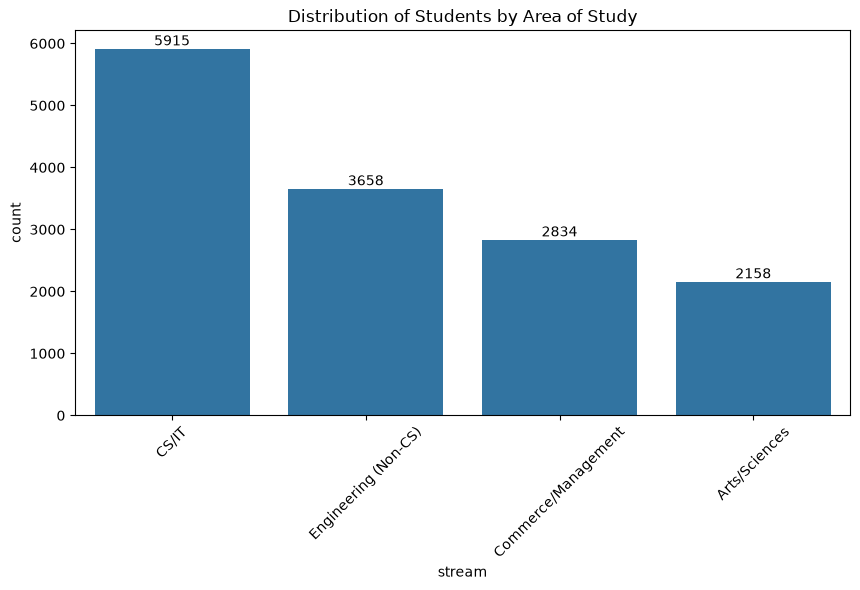

In [107]:
plt.figure(figsize=(10,5))

plot = sns.countplot(
    data=df,
    x="stream",
    order=df["stream"].value_counts().index
)

plot.bar_label(ax.containers[0])

plt.xticks(rotation=45)
plt.title("Distribution of Students by Area of Study")
plt.show()

In [121]:
df["stream"].value_counts(normalize=True).mul(100).round(1)

stream
CS/IT                   40.6
Engineering (Non-CS)    25.1
Commerce/Management     19.5
Arts/Sciences           14.8
Name: proportion, dtype: float64

Considering that the dataset consists of many different majors and disciplines, it is important to know whether it is balanced across these different areas of study.

Out of the 14,565 students observed, there are 5915 CS/IT majors (40.6%), 3658 Engineering (non-CS) majors (25.1%), 2834 Commerce/Management majors (19.5%), and 2158 Arts/Sciences majors (14.8%).

This means that the dataset is not balanced.

Going forward, it is important to consider this distribution when interpreting any results. Since CS/IT make up the greatest proportion of the dataset, trends may be more influenced by this group overall. Therefore, when investigating relationships between AI usage, career anxiety, and student habits, I will examine the overall dataset and each individual study discipline.

Additionally, I am not going to remove any records or balance the dataset. This is because each area of study still has a substantial amount of student records for decent comparisons. Instead, when needed, I will utilize percentages or other methods if and when needed, so that the comparisons drawn are not just based on the number of students in each group.

### AI Usage by Area of Study

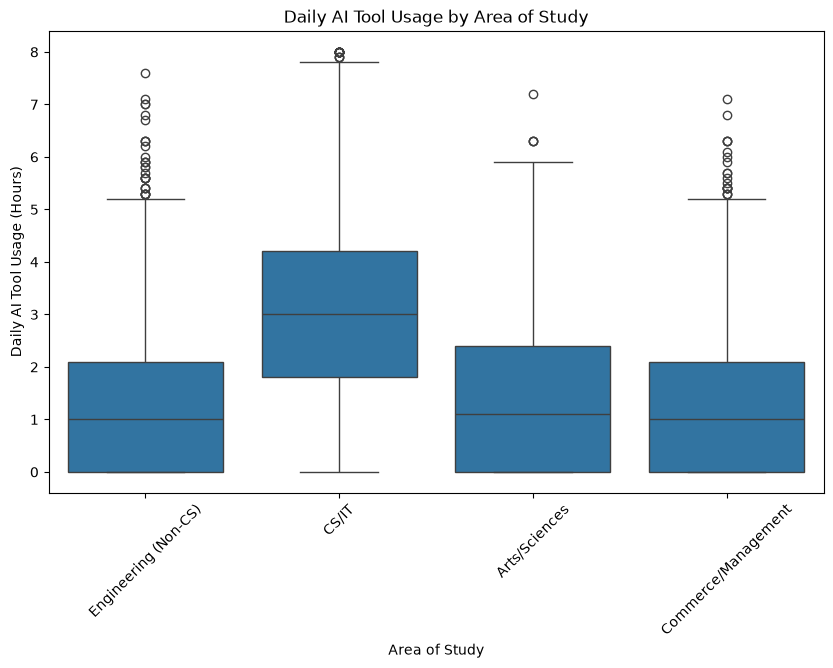

In [108]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="stream",
    y="daily_ai_tool_usage_hrs"
)

plt.xticks(rotation=45)
plt.title("Daily AI Tool Usage by Area of Study")
plt.xlabel("Area of Study")
plt.ylabel("Daily AI Tool Usage (Hours)")

plt.show()

The daily AI usage differs across the four areas of study. CS/IT students have the highest daily median with 3 hrs, while Engineering (non-cs), Arts/Sciences, and Commerce/Management all have a median of approximately 1 hr.

There are also some high usage students in each domain. Engineering and Commerce/Management both have numerous outliers ranging from approximately 5.5-7.5 hrs. Meanwhile, Arts/Sciences has 2 outliers ranging from 6-7 hrs. Lastly, CS/IT has 2 outliers ranging around 8 hrs of AI use per day.

These results ultimately suggest that AI use differs greatly amongst different majors. CS/IT students having a higher median is likely due to them using AI more for school work or to prepare for professional settings. They also have one of the most "computer-oriented" and technical majors, therefore, they may use AI to guide them through their processes more. Additionally, this does not necessarily mean that they are more dependent on AI, they simply use it more.

Additionally, it is also important to note that the dataset is imbalanced and due to this, we may see less variation in other streams (areas of study).

Lastly, this visualization only shows differences in AI usage and does not determine whether higher AI usage is associated with greater career anxiety. This will need to be explored more.

### Career Placement Anxiety by Area of Study

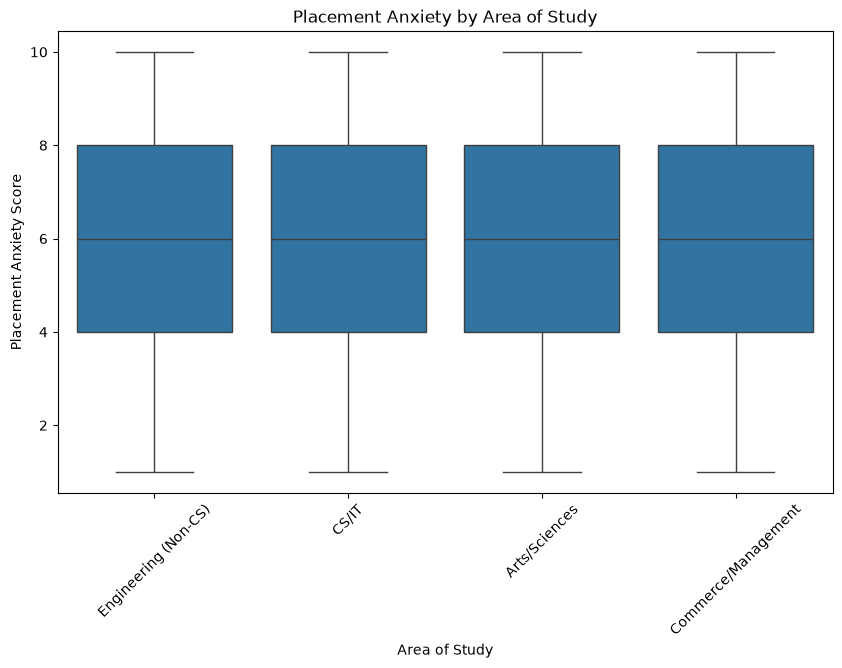

In [109]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="stream",
    y="placement_anxiety_score"
)

plt.xticks(rotation=45)
plt.title("Placement Anxiety by Area of Study")
plt.xlabel("Area of Study")
plt.ylabel("Placement Anxiety Score")

plt.show()

This is interesting as I would have expected some variation, however, placement anxiety appears to be similar amongst all four study disciplines. Each area of study has a median of approximately 6, and similar distribution shapes with no outliers.

This suggests that, from a macro-level, placement anxiety does not differ much between areas of study in this dataset.

However, since the primary research question is regarding the relationship between AI usage and career anxiety, as the next step, I will compare AI usage with placement anxiety rather than only comparing anxiety between study disciplines.

### AI Usage vs Placement Anxiety

To investigate whether AI usage is associated with career anxiety, I will examine the relationship between daily AI tool usage and placement anxiety across the entire dataset first.

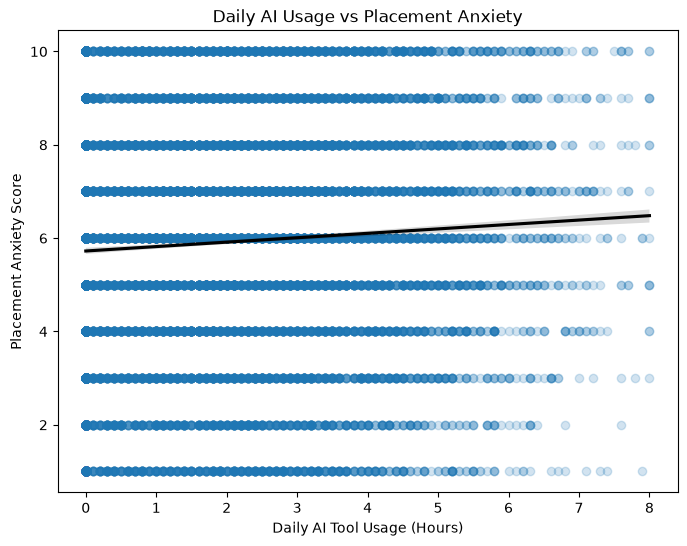

In [110]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="daily_ai_tool_usage_hrs",
    y="placement_anxiety_score",
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "black"}
)

plt.title("Daily AI Usage vs Placement Anxiety")
plt.xlabel("Daily AI Tool Usage (Hours)")
plt.ylabel("Placement Anxiety Score")

plt.show()

The regression line makes the relationship between the two variables easier to idenitfy, and in this instance, the overall relationship between daily AI tool usage and placement anxiety shows a slight positive trend. As daily AI usage increases, placement anxiety also appears to increase slightly.

However, the relationship does not appear to be particularly strong based on the visualization. Therefore, daily AI tool usage should not be considered a cause for placement anxiety. Instead, the relationship between the two variables should be viewed more as an association.

This relationship still needs to be observed by study area, to verify whether findings are consistent across all domains.

### AI Usage vs Placement Anxiety by Study Area

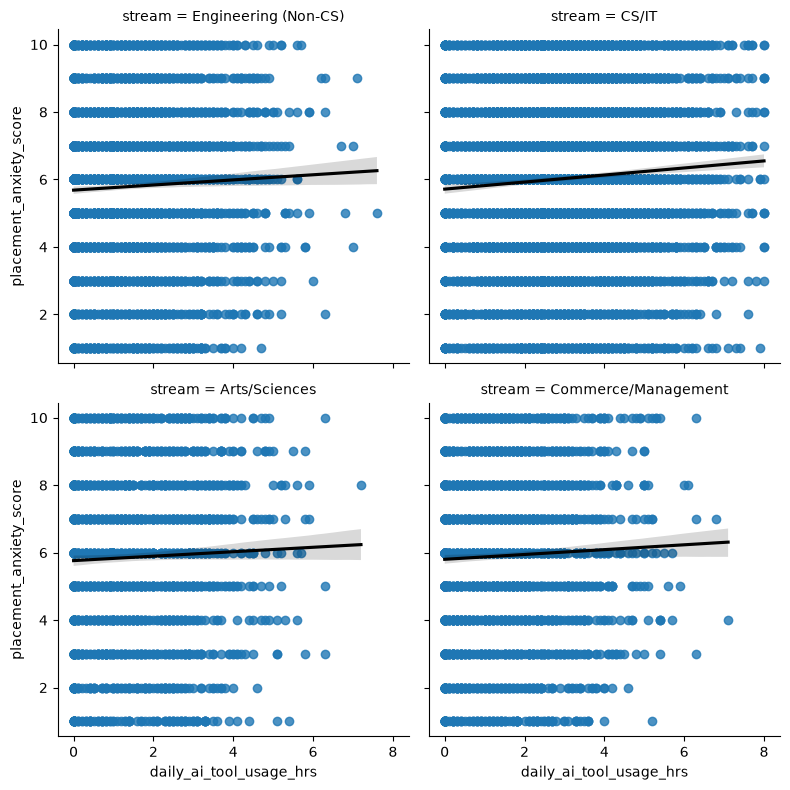

In [111]:
sns.lmplot(
    data=df,
    x="daily_ai_tool_usage_hrs",
    y="placement_anxiety_score",
    col="stream",
    col_wrap=2,
    height=4,
    line_kws={"color": "black"}
)

When observing the relationship between daily AI usage and placement anxiety, all four areas of study show a positive association. It is also notable, however, that all of the slopes are relatively shallow. This suggests that the association between AI usage and placement anxiety is weak, although it does exist.

Additionally, CS/IT students do have a higher median level of daily AI usage than other streams, however, their placement anxiety does not appear to be much different. This suggests that higher AI usage among CS/IT students does not necessarily correspond to higher placement anxiety.

Overall, placement anxiety appears to have a positive, yet relatively weak relationship with daily AI usage.

### AI Usage vs Interview Anxiety by Study Area

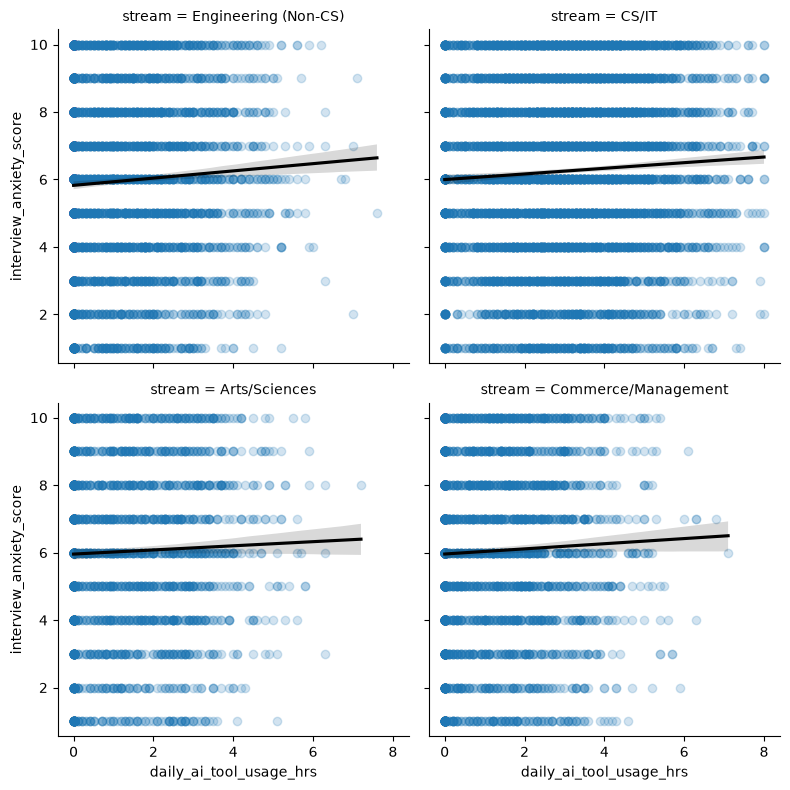

In [112]:
sns.lmplot(
    data=df,
    x="daily_ai_tool_usage_hrs",
    y="interview_anxiety_score",
    col="stream",
    col_wrap=2,
    height=4,
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "black"}
)

When examining the relationship between interview anxiety and daily AI usage by area of study, all four groups show a positive relationship. This suggests that students who report greater daily AI usage also tend to report somewhat higher interview anxiety.

The strength of this relationshp also appears to vary between different domains. Engineering (non-CS) and CS/IT show noticeable positive trends. On the other hand, Arts/Sciences and Commerce/Management show positive yet somewhat shallower relationships.

Overall, the findings suggest that there is a realtively stronger relationship between AI usage and interview anxiety, however, the variation within each AI usage level also suggests that AI usage is not the only factor associated with interview anxiety.

### AI Usage vs Burnout by Study Area

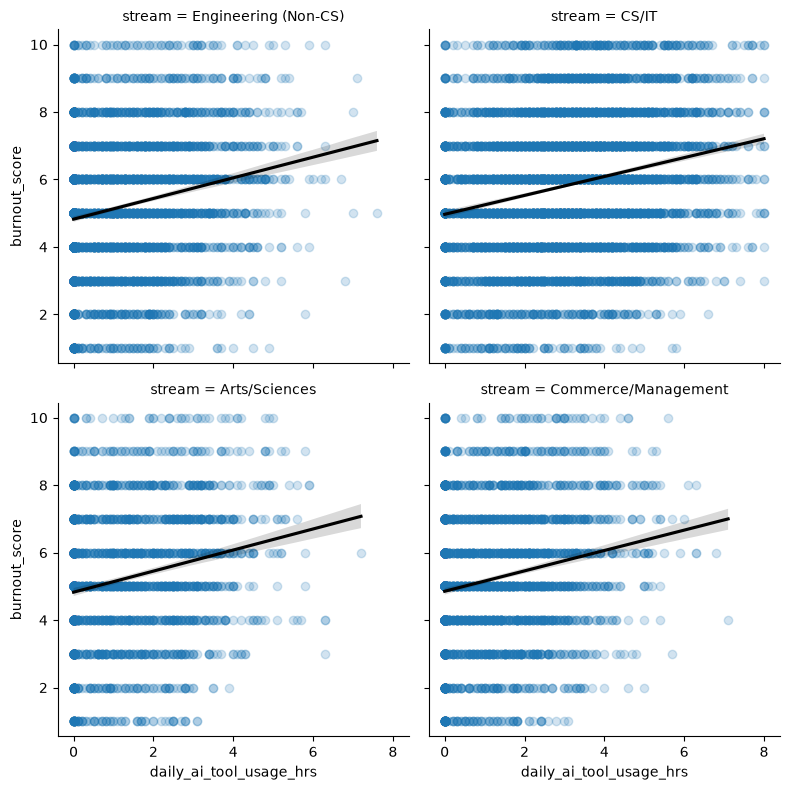

In [113]:
sns.lmplot(
    data=df,
    x="daily_ai_tool_usage_hrs",
    y="burnout_score",
    col="stream",
    col_wrap=2,
    height=4,
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "black"}
)

The relationship between daily AI tool usage and burnout appears stronger than the relationships previosuly observed with interview and placement anxiety. All four areas of study show a strong positive trend, suggesting that students with higher daily AI usage tend to report higher burnout scores and that this pattern is not limited to a single domain of study.

Overall, due to the strong positive relationships, this may also suggest that AI usage is more closely associated with academic or career-related burnout rather than with anxiety specifically.

### AI Usage vs Fear of Job Loss to AI by Study Area

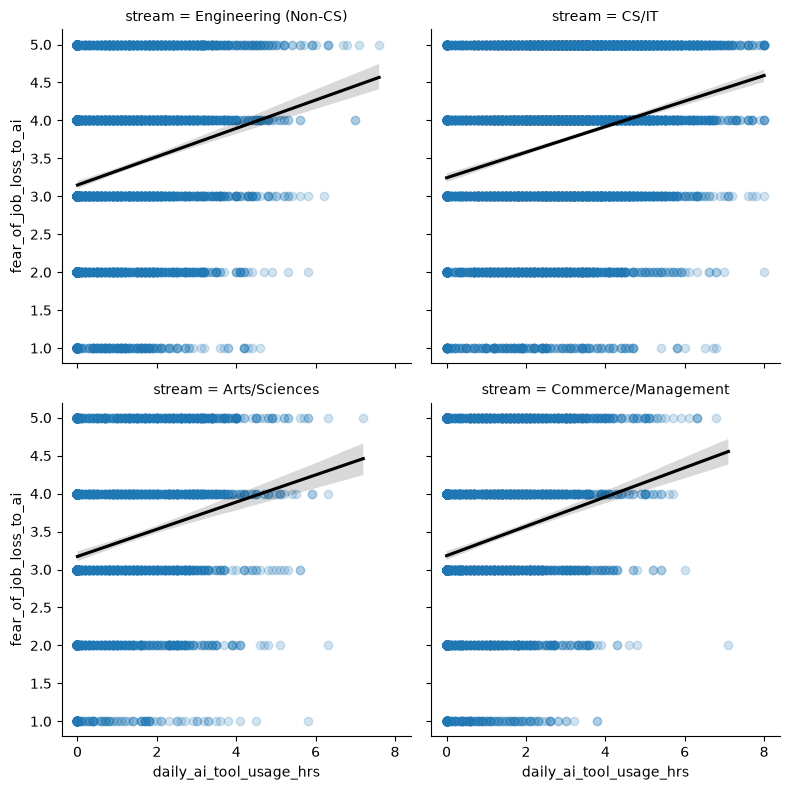

In [114]:
sns.lmplot(
    data=df,
    x="daily_ai_tool_usage_hrs",
    y="fear_of_job_loss_to_ai",
    col="stream",
    col_wrap=2,
    height=4,
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "black"}
)

The relationship between daily AI usage and fear of job loss to AI also shows a positive trend across all four areas of study. Students with greater daily AI usage report higher levels of fear that AI could replace their job.

This relationship is highly noticeable in Arts/Sciences and Commerce/Management and Engineering (non-CS), while CS/IT has just a slightly flatter trend.

This relationship is also important because fear of AI related job loss also is a form of career anxiety, and the findings suggest that students who use AI more, also have greater concern about its impact on their future careers.

## Overall Findings: AI Usage and Career Anxiety

Overall, daily AI tool usage has a positive association with different forms of career-related anxiety, and the strength of the relationship differs depending on the type of anxiety being measured.

The clearest positive relationships are with burnout and fear of job loss to AI, and interview anxiety also shows a positive trend. Meanwhile, placement anxiety shows has the weakest relationship with AI usage but is still positive across all four areas of study.

These findings were all generally consistent across the different areas of study rather than being specific to a single domain. However, the strength of the trends varied between the different areas. This suggests that area of study may influence the relationship between AI usage and particular forms of career anxiety, however, it does not appear to be by a substantial amount.

Another important observation was that CS/IT students had a substantially higher daily AI usage median than the other areas of study. However, despite this, placement anxiety still appeared relatively similar across all four groups. This suggests that greater AI usage does not automatically correspond to greater placement anxiety.

Overall, there appears to be positive associations between AI usage and career-related anxiety, particularly burnout, fear of job loss to AI, and interview anxiety.

### Primary AI Tool Distribution

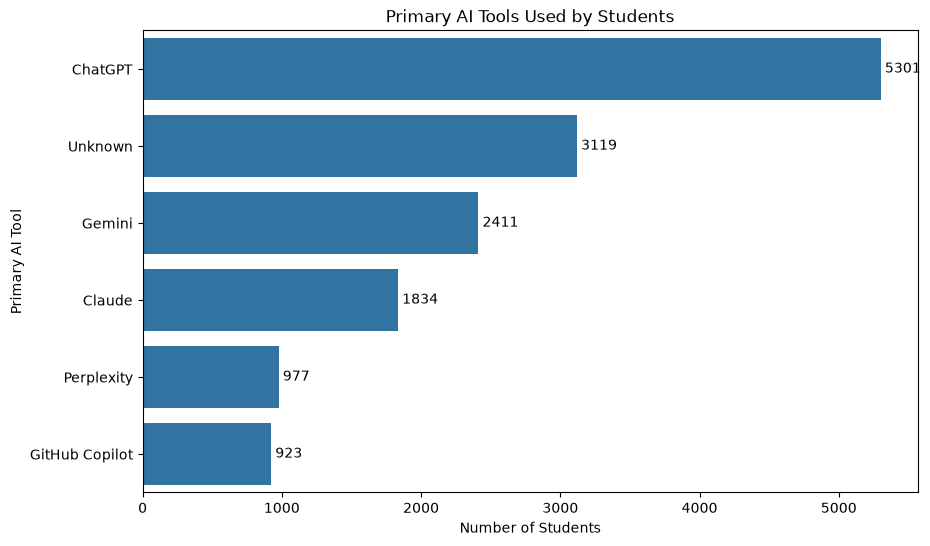

In [115]:
plt.figure(figsize=(10,6))

plot = sns.countplot(
    data=df,
    y="primary_ai_tools_used",
    order=df["primary_ai_tools_used"].value_counts().index
)

plot.bar_label(plot.containers[0], padding=3)

plt.title("Primary AI Tools Used by Students")
plt.xlabel("Number of Students")
plt.ylabel("Primary AI Tool")

plt.show()

In [122]:
df["primary_ai_tools_used"].value_counts(normalize=True).mul(100).round(1)

primary_ai_tools_used
ChatGPT           36.4
Unknown           21.4
Gemini            16.6
Claude            12.6
Perplexity         6.7
GitHub Copilot     6.3
Name: proportion, dtype: float64

The most commonly reported primary AI tool in the dataset is ChatGPT with 5,301 students identifying it as their primary tool (36.4%). Gemini is the second most common tool with 2,411 students (16.6%). Next is Claude with 1,834 (12.6%). Lastly, Perplexity (6.7%) and GitHub Copilot (6.3%) are less frequently used, with 977 and 923 students.

There are also 3,119 records where the primary AI tool is recorded as "Unknown" (21.4%). This is due to the missing values that were retained as a separate category during data cleaning rather than being removed from the dataset.

Overall, the distribution is highly uneven across AI tools, therefore, going forward, it is important to consider this distribution when interpreting any results as they may be skewed.

### Primary AI Tool vs Burnout

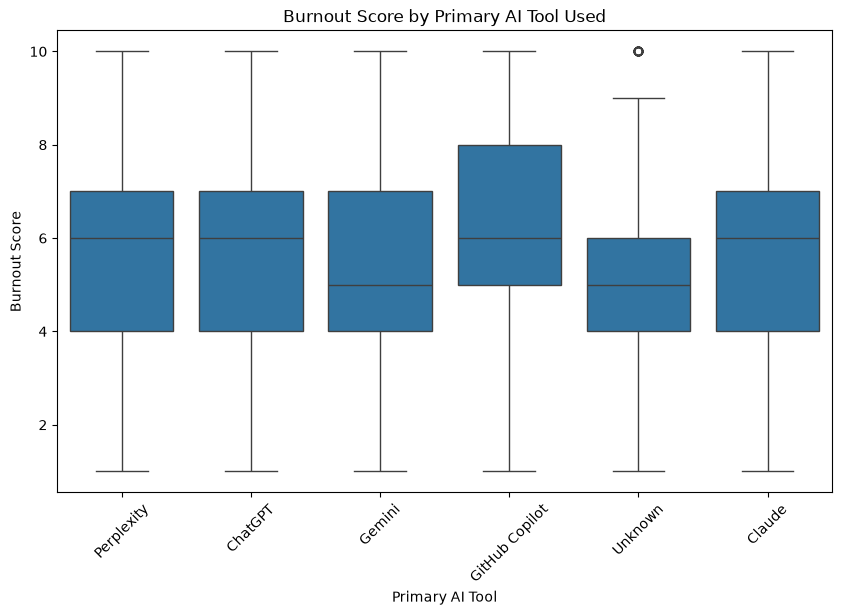

In [116]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="primary_ai_tools_used",
    y="burnout_score"
)

plt.xticks(rotation=45)
plt.title("Burnout Score by Primary AI Tool Used")
plt.xlabel("Primary AI Tool")
plt.ylabel("Burnout Score")

plt.show()

Most tools have burnout score medians between approximately 5 and 6, with ChatGPT, Perplexity, GitHub Copilot, and Claude having medians around 6, while Gemini and the Unknown group have medians around 5.

Although there are some differences in the distributions, the large overlap between different tools suggests that the choice of primary AI tool does not appear to be strongly associated with burnout based on this visualization alone.

This is different from the earlier analysis with daily AI usage, where burnout showed a clear positive relationship with the amount of AI used. The current result suggests that the amount of AI usage may be more relevant to burnout than the specific AI tool being used.

### Primary AI Tool vs Interview Anxiety

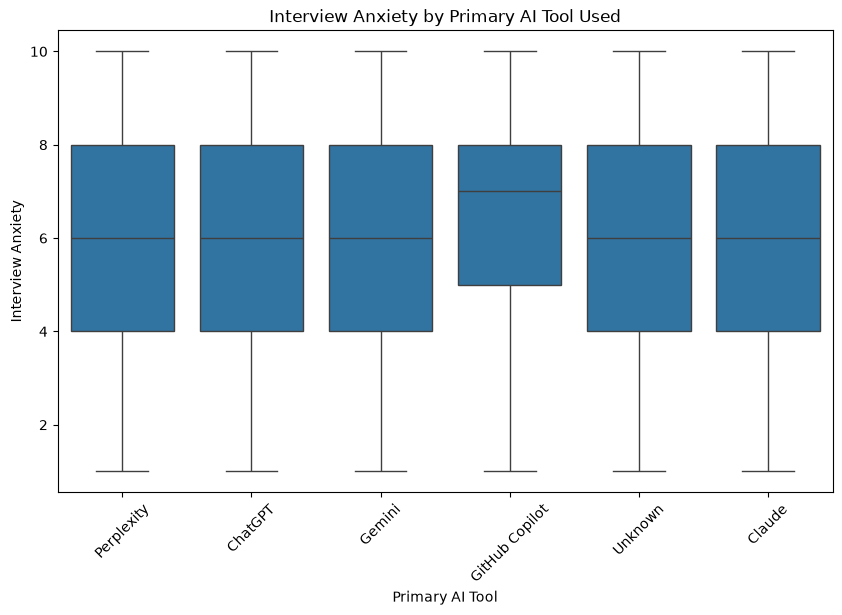

In [117]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="primary_ai_tools_used",
    y="interview_anxiety_score"
)

plt.xticks(rotation=45)
plt.title("Interview Anxiety by Primary AI Tool Used")
plt.xlabel("Primary AI Tool")
plt.ylabel("Interview Anxiety")

plt.show()

Interview anxiety is also relatively similar across the different primary AI tools. Most tools have a median interview anxiety score of approximately 6. GitHub Copilot has a somewhat higher median with approximately 7, however, its distribution still overlaps quite a bit with the other groups.

The similar distributions suggest that the specific AI tool used also may not be strongly associated with interview anxiety. 

Additionally, the higher median observed for GitHub Copilot should also be interpreted cautiously because it is based on a much smaller group/count than ChatGPT.

### Primary AI Tool vs Placement Anxiety

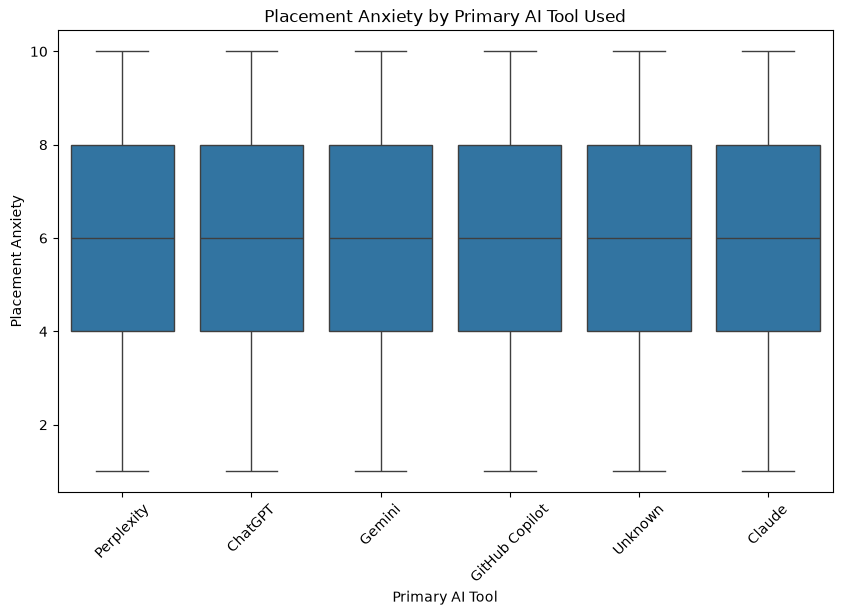

In [118]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="primary_ai_tools_used",
    y="placement_anxiety_score"
)

plt.xticks(rotation=45)
plt.title("Placement Anxiety by Primary AI Tool Used")
plt.xlabel("Primary AI Tool")
plt.ylabel("Placement Anxiety")

plt.show()

Placement anxiety is also consistent across students using different primary AI tools. Each group has a median placement anxiety score of approximately 6 and the distributions are also highly similar.

This finding is also consistent with the earlier analysis of dialy ai usage vs placement anxiety by area of study, where the four academic groups also showed very similar distributions. Overall, these results suggest that placement anxiety may not be strongly differentiated by either ai usage, area of study, or primary AI tool.

### Primary AI Tool vs Fear of Job Loss to AI

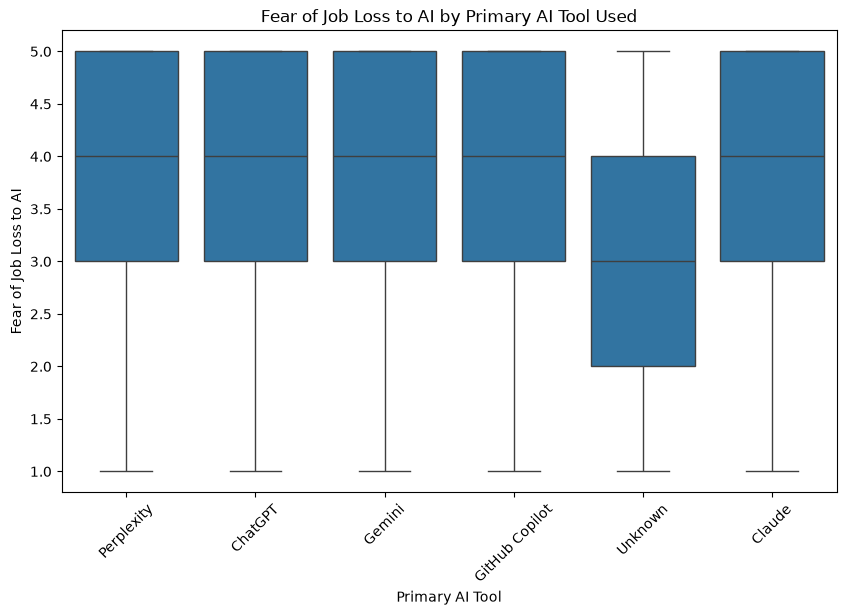

In [120]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="primary_ai_tools_used",
    y="fear_of_job_loss_to_ai"
)

plt.xticks(rotation=45)
plt.title("Fear of Job Loss to AI by Primary AI Tool Used")
plt.xlabel("Primary AI Tool")
plt.ylabel("Fear of Job Loss to AI")

plt.show()

Fear of job loss to AI is also quite consistent among different primary AI tools. Most groups have a median of 4, with the only exception being "Unknown" that has a median of 3. 

I am taking this with a grain of salt because "Unknown" was formerly missing values, hence it does not provide much meaningful insight that can be applied.

Overall, these findings suggest that the type of AI tool used does not have a great impact on fear of job loss to AI.

## Overall Findings: Primary AI Tool and Career Anxiety

The analysis of primary AI tools suggests that the specific AI platform used by a student does not appear to produce large differences in most career anxiety measures. Burnout, interview anxiety, placement anxiety, and fear of job loss to AI distributions all overlap substantially across the different AI tools.

Placement anxiety shows the most consistentency, with a median of approximately 6 across all AI-tool groups. This is also consistent with the earlier finding that placement anxiety also has similar distributions across daily AI usage averages and areas of study. Therefore, placement anxiety does not appear to be strongly differentiated by either academic area or primary AI tool.

Burnout and interview anxiety show somewhat more variation between AI-tool groups, but the differences are relatively small compared with the variation within each group. This suggests that the specific AI tool may be less important than other characteristics such as the student's AI usage when it comes to anxiety.

Lastly, fear of job loss to AI is also fairly consistent, with most AI-tool groups having a median of 4 and similar distributions. The only outstanding finding here was "Unknown" having a median of 3, however, this is insiginificant because this category was previously missing values, hence, we can not draw any meaningful or concrete conclusions from it.

It is also important to note that the distribution of primary AI tools is also highly uneven. ChatGPT is much more common than the other tools, while Perplexity and GitHub Copilot have comparatively small groups. Therefore, interpretations involving less frequently used tools should be done cautiously.

When compared with the previous analysis of daily AI usage, the results suggest that the amount of AI usage may be more informative for understanding career-related anxiety than the specific AI platform used. Daily AI usage showed positive trends with several anxiety measures, particularly burnout, interview anxiety, and fear of job loss to AI, whereas comparisons between primary AI tools showed more overlap.

## Part 1 Conclusion

### Overall relationship between amount of AI usage and anxiety

Daily AI tool usage shows a generally positive relationship with several different anxiety-related measures. The strongest positive relationships appear to happen for burnout, fear of job loss to AI, and interview anxiety. On the other hand, placement anxiety shows a weaker positive relationship.

This suggests that students who use AI more daily may also experience more specific career concerns such as interview anxiety, concern about AI replacing future employment, and greater burnout.

### Differences across areas of study

The relationship between AI usage and anxiety is generally visible across all four areas of study rather than being isolated to one group.

CS/IT students have the highest median daily AI usage at approximately 3 hours per day, compared with approximately 1 hour for Engineering (non-CS), Arts/Sciences, and Commerce/Management. Despite this difference in AI usage, placement anxiety distributions are very similar across the four areas, with a median of approximately 6.

This suggests that higher AI usage within CS/IT does not automatically correspond to higher placement anxiety.

For burnout, however, all four areas show positive relationships with daily AI usage. Interview anxiety also shows positive trends across the four groups. Fear of job loss to AI similarly shows positive relationships with daily AI usage.

Therefore, the relationship between AI usage and career anxiety appears to be relatively consistent across academic areas, although the strength of the relationship varies depending on the type of anxiety being measured.

### Differences between AI tools

The analysis of primary AI tools produces a different pattern. Burnout, interview anxiety, placement anxiety distributions, fear of AI replacement all overlap between students using different AI tools. Placement anxiety is particularly consistent, with a median of approximately 6 across the tool groups.

This suggests that the specific AI platform a student primarily uses may be less important than the amount or nature of their AI usage.

### Conclusion

Overall, the EDA suggests that the amount of AI usage has a much more noticeable association with different forms of career-related anxiety in comparison to the specific AI tool used. Higher AI usage is associated with higher burnout, interview anxiety, and fear of job loss to AI across multiple areas of study. Additionally, the relationships that both AI usage and AI tools have with placement anxiety appears weaker.

## Part 2: Identify different student habits which can lower anxiety and contribute to high career readiness scores

I am going to start off by making a correlation matrix and heatmap so I can have a better idea of the relationships within the dataset, and see which variables and habits are worth investigating.

In [125]:
habit_vars = [
    "daily_study_hours",
    "self_learning_hours_per_week",
    "skill_development_courses_taken",
    "social_media_hrs_per_day",
    "sleep_hours",
    "weekly_job_application_count",
    "motivation_score",
    "internship_experience",
    "career_clarity_score",
    "resume_confidence_score"
]

outcome_vars = [
    "overall_career_readiness_score",
    "placement_anxiety_score",
    "interview_anxiety_score",
    "burnout_score",
    "stress_level",
    "fear_of_job_loss_to_ai"
]

In [126]:
results = []

for habit in habit_vars:
    for outcome in outcome_vars:
        rho, p = spearmanr(df[habit], df[outcome])
        
        results.append({
            "habit": habit,
            "outcome": outcome,
            "spearman_rho": rho,
            "p_value": p
        })

correlation_df = pd.DataFrame(results)

correlation_df

,habit,outcome,spearman_rho,p_value
0,daily_study_hours,overall_career_readiness_score,0.459773,0.000000e+00
1,daily_study_hours,placement_anxiety_score,-0.098227,1.463169e-32
2,daily_study_hours,interview_anxiety_score,-0.169652,1.726120e-94
3,daily_study_hours,burnout_score,-0.112063,6.372627e-42
4,daily_study_hours,stress_level,0.119545,1.667396e-47
5,daily_study_hours,fear_of_job_loss_to_ai,-0.049586,2.131644e-09
6,self_learning_hours_per_week,overall_career_readiness_score,0.381719,0.000000e+00
7,self_learning_hours_per_week,placement_anxiety_score,-0.035893,1.471911e-05
8,self_learning_hours_per_week,interview_anxiety_score,-0.066721,7.592530e-16
9,self_learning_hours_per_week,burnout_score,0.051222,6.200705e-10


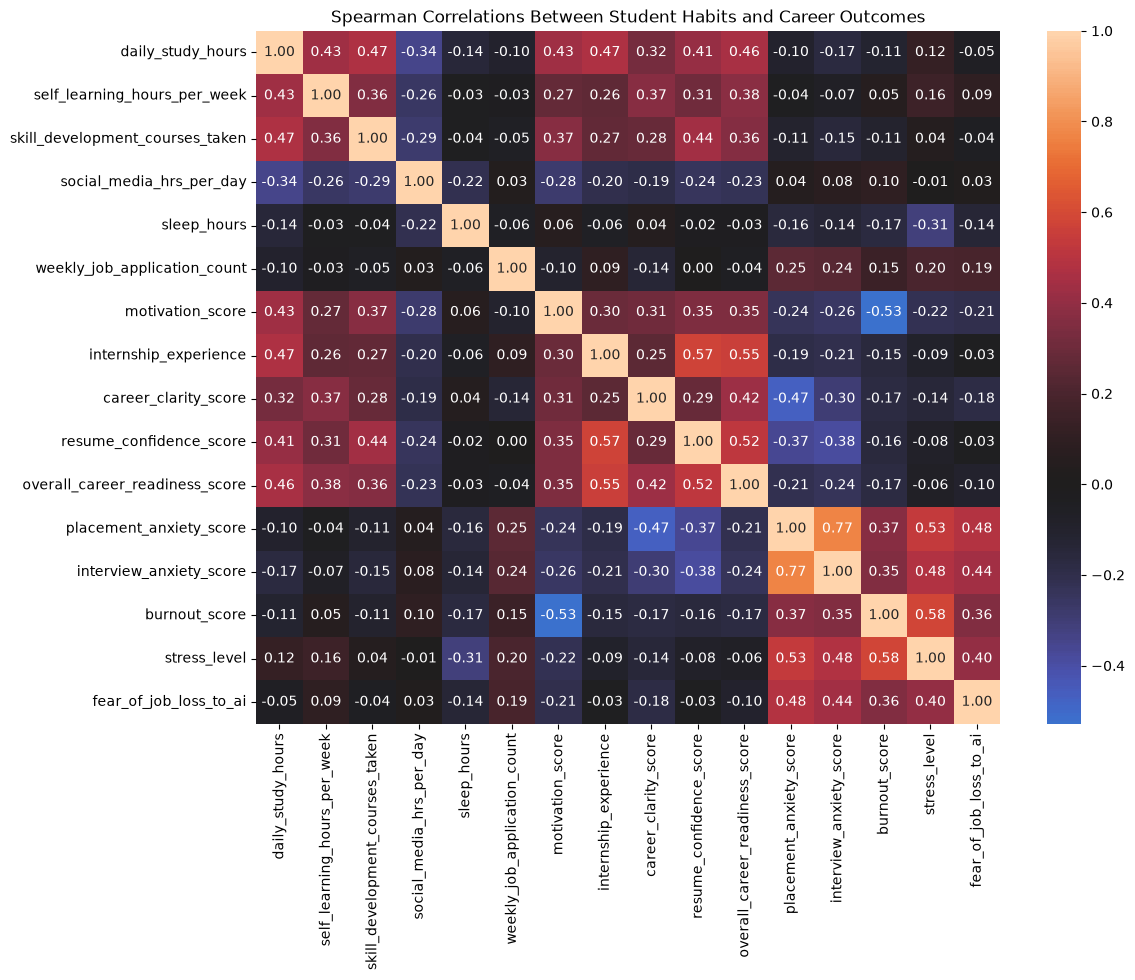

In [128]:
correlation_matrix = df[
    habit_vars + outcome_vars
].corr(method="spearman")

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Spearman Correlations Between Student Habits and Career Outcomes")
plt.show()

Because numerous outcome variables were ordinal scores, I decided to use Spearman correlation to identify monotonic relationships. This gave me an initial way of determining which habits I should further investigate without assuming that any of the relationships are linear.

#### Career Readiness

From the correlation matrix and heatmap, some varibales worth investigating that stand out are daily study hours (p=0.36), self-learning (p=0.38), skill-development courses (p=0.36), and internship experience (p=0.55). Although some of these are not habits like the client had asked, they all have strong positive realtionships with the overall_career_readiness_score and could provide valuable insight.

#### Anxiety and Stress

From the correlation matrix and heatmap, some variables worth investigating are sleep (p=-0.31 with stress), motivation (p=-0.53 with burnout), career clarity (p=-0.47 with placement anxiety), and resume confidence (p=-0.38 with interview anxiety). Although all of these are also not necessarily habits, they do have strong negative relationships with anxiety and stress measures and could provide valuable insight as well.

#### Habits vs Non-Habits

Due to there being some relationships that are not habits, I will be breaking this section into different categories to explore.

##### Learning Habits
- daily study hours
- self-learning hours
- skill-development courses

##### Wellbeing Habits
- sleep

##### Career Preperation
- career clarity
- resume confidence
- motivation
- internship experience

### Learning Habits

### Daily Study Hours vs Career Readiness

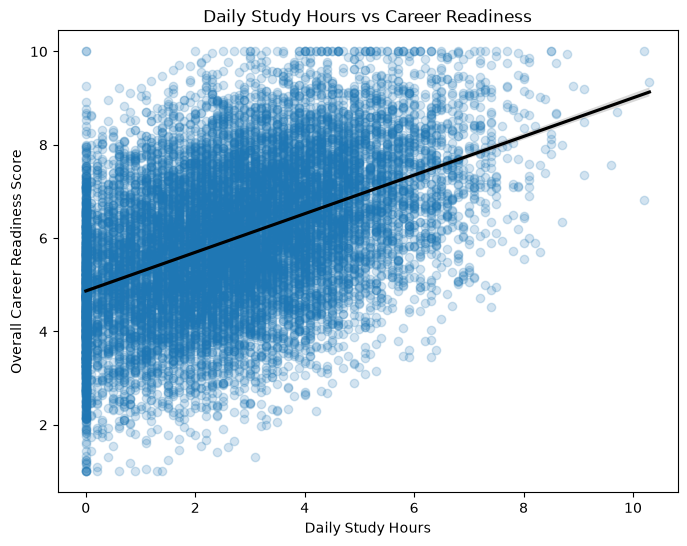

In [129]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x="daily_study_hours",
    y="overall_career_readiness_score",
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "black"}
)

plt.title("Daily Study Hours vs Career Readiness")
plt.xlabel("Daily Study Hours")
plt.ylabel("Overall Career Readiness Score")

plt.show()

The relationship between daily study hours and overall career readiness shows a clear positive association. As daily study hours increase, career readiness scores also tends to increase. The Spearman correlation between these variables is 0.46 which indicates a moderately positive relationship.

This suggests that students who spend more time studying each day generally have higher levels of career readiness. This may be because consistent studying helps students build knowledge, confidence, and prepare for future professional responsibilities.

However, it is important to remember that other factors may also contribute to career readiness, not explicitly studying.

### Self-Learning Hours vs Career Readiness

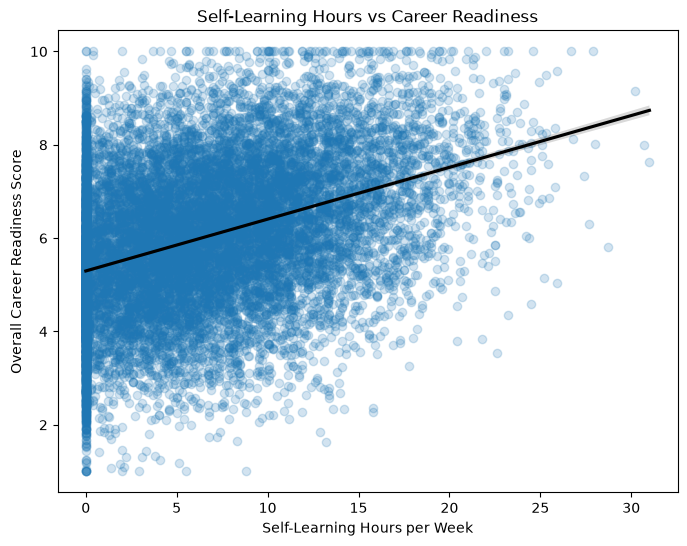

In [130]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x="self_learning_hours_per_week",
    y="overall_career_readiness_score",
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "black"}
)

plt.title("Self-Learning Hours vs Career Readiness")
plt.xlabel("Self-Learning Hours per Week")
plt.ylabel("Overall Career Readiness Score")

plt.show()

Self-learning hours also show a positive relationship with overall career readiness. The regression line indicates that students who spend more time on self-learning generally have higher career readiness scores. The Spearman correlation is 0.38 which also represents a moderate positive relationship.

This suggests that independently learning outside of regular coursework may help students feel more prepared for their careers. Self-learning could include developing additional knowledge or skills which likely contributes to greater confidence when preparing for professional duties.

However, the relationship is not extremely strong. This means that self-learning alone does not explain career readiness and other factors likely have a contribution in how prepared the student feels.

### Skill-Development Courses vs Career Readiness

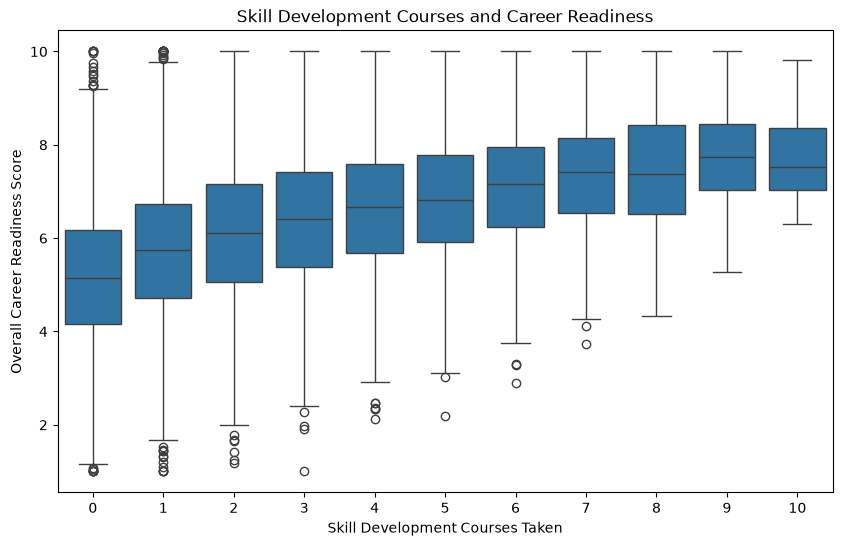

In [133]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="skill_development_courses_taken",
    y="overall_career_readiness_score"
)

plt.title("Skill Development Courses and Career Readiness")
plt.xlabel("Skill Development Courses Taken")
plt.ylabel("Overall Career Readiness Score")

plt.show()

The boxplot shows a generally increasing trend in career readiness as the number of skill development courses taken increases. Students who have completed more courses tend to have a higher median career readiness scores.

The Spearman correlation between skill development courses and career readiness is approximately 0.36 which also shows a moderate positive association. This suggests that actively developing additional skills is also associated with feeling more prepared for entering professions.

However, it is important to note that the distributions still overlap between groups. This means that taking more courses does not guarantee a higher career readiness score. Regardless, the overall positive trend still hints that skill development is a likely valuable habit for students to prepare them for their careers.

### Wellbeing Habits

### Sleep vs Stress

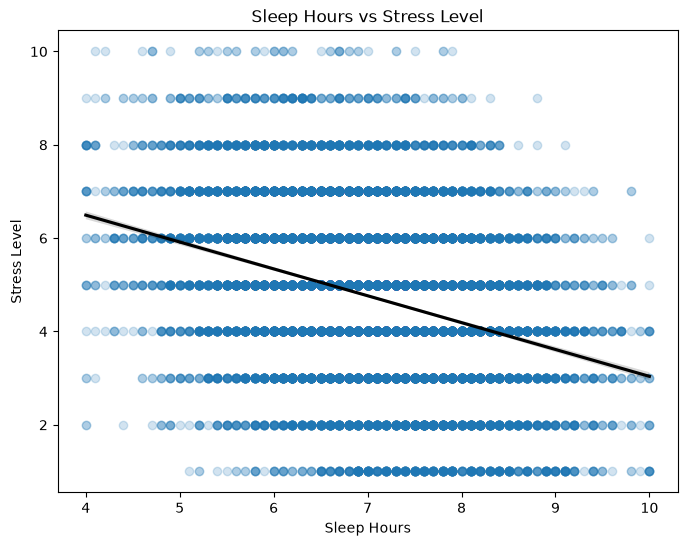

In [134]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x="sleep_hours",
    y="stress_level",
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "black"}
)

plt.title("Sleep Hours vs Stress Level")
plt.xlabel("Sleep Hours")
plt.ylabel("Stress Level")

plt.show()

Sleep has one of the clearest negative relationships with stress in this dataset. As sleep hours increase, stress levels generally decrease. The Spearman correlation is approximately -0.31 which indicates a moderate negative association.

This suggests that students who report getting more sleep also tend to report lower levels of stress. In contrast, students with fewer hours of sleep tend to have higher stress scores.

However, it is important that this relationship is not interpreted as evidence that increasing sleep directly decreases stress. Instead, stress itself can also influence students' ability to sleep.

### Sleep vs Burnout

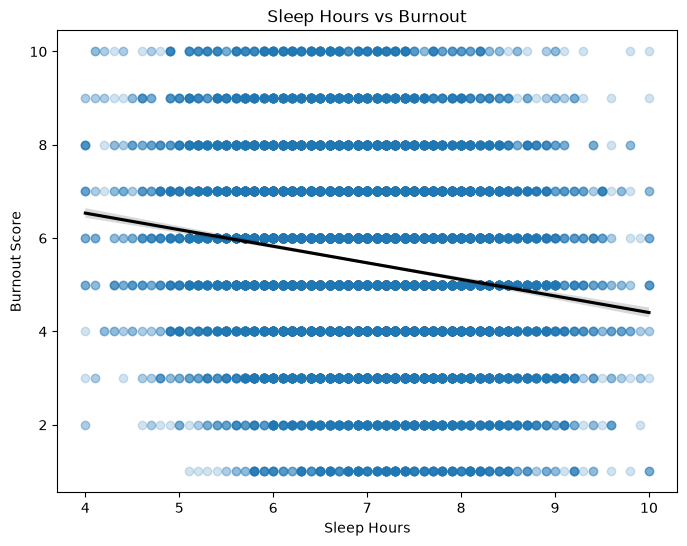

In [136]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x="sleep_hours",
    y="burnout_score",
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "black"}
)

plt.title("Sleep Hours vs Burnout")
plt.xlabel("Sleep Hours")
plt.ylabel("Burnout Score")

plt.show()

Sleep hours also show a negative relationship with burnout. The regression line slopes downward, indicating that students who sleep more generally tend to have lower burnout scores.

However, the Spearman correlation between sleep and burnout is approximately -0.17, which represents a relatively weak negative relationship when compared with the one between sleep and stress.

Additionally, although the relationship is not particularly strong, this finding does support the idea that students who get more sleep tend to experience less burnout which indicates that sleep is an important part of maintaining student mental health, particularly for students balancing academic and career preparation.

### Sleep vs Interview Anxiety

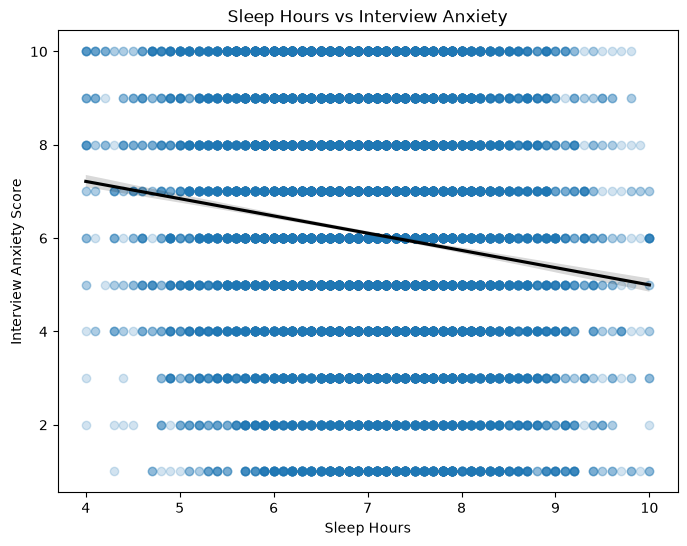

In [138]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x="sleep_hours",
    y="interview_anxiety_score",
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "black"}
)

plt.title("Sleep Hours vs Interview Anxiety")
plt.xlabel("Sleep Hours")
plt.ylabel("Interview Anxiety Score")

plt.show()

There is also a negative relationship between sleep hours and interview anxiety. The regression line indicates that interview anxiety generally decreases as reported sleep hours increase.

The Spearman correlation is approximately -0.14, indicating a relatively weak negative association. This means that students who sleep more tend to have somewhat lower interview anxiety, and students who sleep less have higher interview anxiety. 

Although this is not the strongest relationship, it does show that sleep has some correlation to an aspect anxiety.

### Sleep vs Placement Anxiety

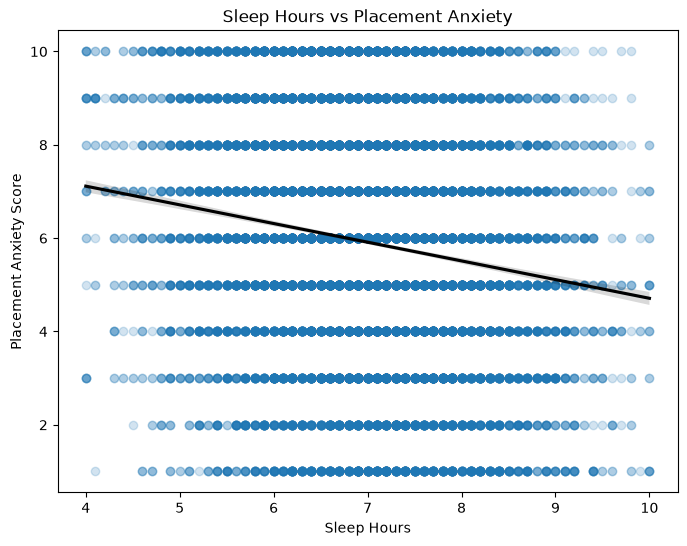

In [139]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x="sleep_hours",
    y="placement_anxiety_score",
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "black"}
)

plt.title("Sleep Hours vs Placement Anxiety")
plt.xlabel("Sleep Hours")
plt.ylabel("Placement Anxiety Score")

plt.show()

Sleep hours also has a negative relationship with placement anxiety. As sleep hours increase, placement anxiety generally tends to decrease. The Spearman correlation between the two variables is -0.16 which represents a relatively weak negative relationship.

This suggests that students who get more sleep also have somewhat lower anxiety about career placement. However, the variation in the plot also suggests that sleep is not the only factor causing students' placement anxiety.

### Career Preperation

### Career Clarity vs Placement Anxiety

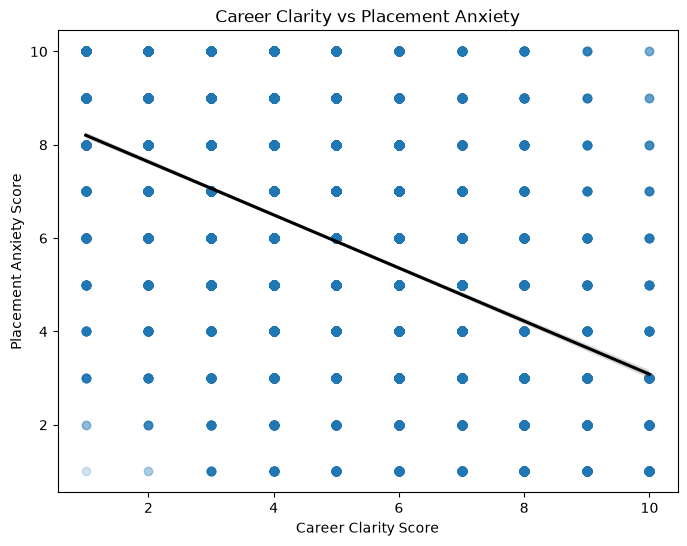

In [140]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x="career_clarity_score",
    y="placement_anxiety_score",
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "black"}
)

plt.title("Career Clarity vs Placement Anxiety")
plt.xlabel("Career Clarity Score")
plt.ylabel("Placement Anxiety Score")

plt.show()

Career clarity shows a relatively strong negative relationship with placement anxiety which means students with higher career clarity scores tend to have lower placement anxiety scores.

The Spearman correlation is approximately -0.47, which makes this one of the stronger negative relationships observed in the matrix/heatmap.

This ultimately suggests that students who have a clearer understanding of their career direction, feel less anxious about securing a future placement. This is probably due to a clearer career path making the job-search process feel more manageable, likely because students have a better understanding of the types of positions, industries, and skills they are targeting.

### Resume Confidence vs Interview Anxiety

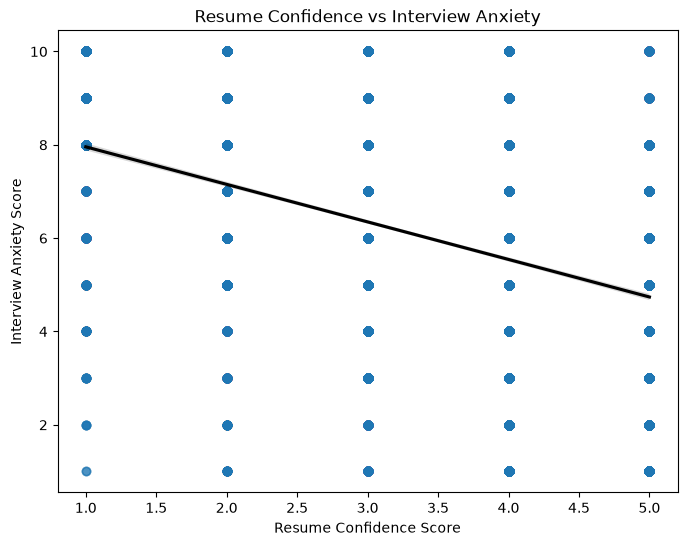

In [141]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x="resume_confidence_score",
    y="interview_anxiety_score",
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "black"}
)

plt.title("Resume Confidence vs Interview Anxiety")
plt.xlabel("Resume Confidence Score")
plt.ylabel("Interview Anxiety Score")

plt.show()

Resume confidence also has a negative relationship with interview anxiety which means students with higher resume confidence scores tend to report lower levels of interview anxiety.

The Spearman correlation is approximately -0.38 which indicates a moderate negative association.

This suggests that students who feel more confident about their resumes may also feel more prepared for the interview process. This is probably due to the fact they have confidence in their qualifications, and their ability to present their experience may reduces some uncertainty.

### Motivation vs Burnout

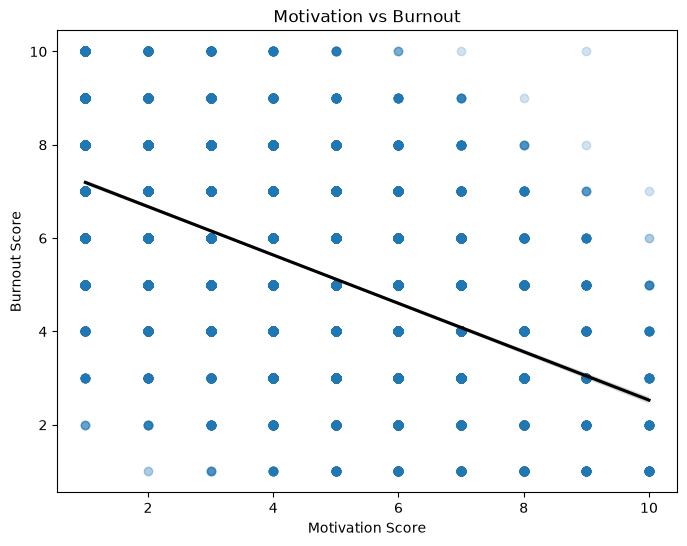

In [143]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x="motivation_score",
    y="burnout_score",
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "black"}
)

plt.title("Motivation vs Burnout")
plt.xlabel("Motivation Score")
plt.ylabel("Burnout Score")

plt.show()

Motivation has the strongest negative relationship with burnout in the dataset.

The Spearman correlation between motivation and burnout is -0.53 which represents a fairly strong negative association.

This suggests that highly motivated students tend to report much lower burnout scores, while students with lower motivation tend to report higher burnout. This is an important observation because burnout can negatively affect a student's ability to maintain consistent academic and career preparation.

However, it is important to remember that although this relationship is strong, it does not represent the sole reason for burnout or motivation.

### Internship Experience vs Career Readiness

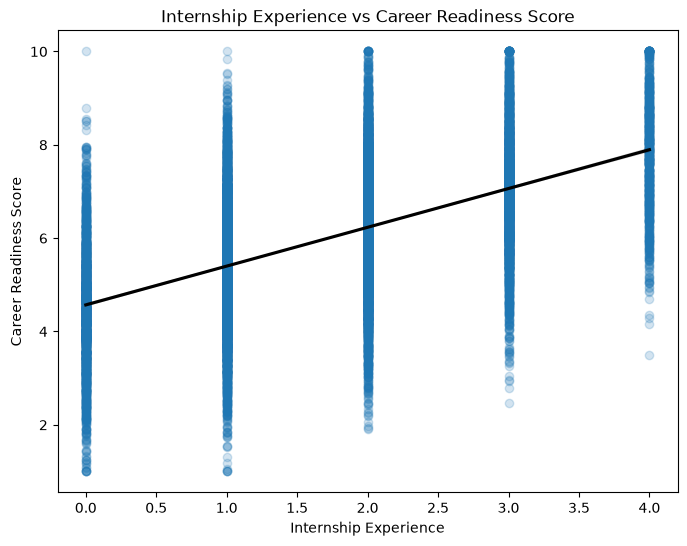

In [144]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x="internship_experience",
    y="overall_career_readiness_score",
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "black"}
)

plt.title("Internship Experience vs Career Readiness Score")
plt.xlabel("Internship Experience")
plt.ylabel("Career Readiness Score")

plt.show()

Internship experience also shows a strong positive relationship with overall career readiness. 

The Spearman correlation between internship experience and career readiness is 0.55 which makes this the strongest positive relationship with career readiness among the variables we examined.

This suggests that gaining practical experience is strongly associated with students feeling more prepared for their careers. Internships give students an opportunity to develop professional skills and experience outside of school, which likely contributes to them feeling more confident.

Overall, internship experience appears to be one of the most strongly associated factors with career readiness in this analysis.

### Compare High Readiness and Low Anxiety Students with the Rest of the Students

In [150]:
habit_vars = [
    "daily_study_hours",
    "self_learning_hours_per_week",
    "skill_development_courses_taken",
    "social_media_hrs_per_day",
    "sleep_hours",
    "weekly_job_application_count"
]

These are the habits I will be comparing between the two groups.

### High Readiness and Low Burnout

In [147]:
readiness_cutoff = df["overall_career_readiness_score"].quantile(0.75)
burnout_cutoff = df["burnout_score"].quantile(0.25)

In [148]:
df["high_readiness_low_burnout"] = (
    (df["overall_career_readiness_score"] >= readiness_cutoff) &
    (df["burnout_score"] <= burnout_cutoff)
)

I took the highest quartile of career readiness and lowest quartile of burnout and made a seperate column where records that have both are true, and records that have one or none of the two are false.

In [151]:
habit_comparison = df.groupby("high_readiness_low_burnout")[habit_vars].mean().T

habit_comparison["difference"] = (
    habit_comparison[True] - habit_comparison[False]
)

habit_comparison

high_readiness_low_burnout,False,True,difference
daily_study_hours,2.591963,3.900999,1.309037
self_learning_hours_per_week,6.068318,8.363158,2.294840
skill_development_courses_taken,1.924602,2.971352,1.046750
social_media_hrs_per_day,3.077557,2.392338,-0.685218
sleep_hours,6.977044,7.128648,0.151604
weekly_job_application_count,10.799985,9.314457,-1.485528


I made a chart that calculates the differences, so it is easier to compare the two groups.

The high-readiness, low-burnout group shows several notable differences. On average, these students reported 3.90 daily study hours, compared with 2.59 hours among the remaining students, a difference of approximately 1.31 hours. They also reported 8.36 hours of self-learning per week, compared with 6.07 hours, and completed an average of 2.97 skill-development courses, compared with 1.92 courses.

In contrast, the high-readiness, low-burnout group reported less social media use, averaging 2.39 hours per day compared with 3.08 hours among the remaining students. They also submitted fewer weekly job applications on average (9.31 compared with 10.80).

The difference in sleep was relatively small with the high-readiness, low-burnout group averaged 7.13 hours of sleep compared with 6.98 hours among the remaining students.

### High Readiness and Low Interview Anxiety

In [152]:
interview_anxiety_cutoff = df["interview_anxiety_score"].quantile(0.25)

In [153]:
df["high_readiness_low_interview_anxiety"] = (
    (df["overall_career_readiness_score"] >= readiness_cutoff) &
    (df["interview_anxiety_score"] <= interview_anxiety_cutoff)
)

I took the highest quartile of career readiness and lowest quartile of interview anxiety and made a seperate column where records that have both are true, and records that have one or none of the two are false.

In [154]:
habit_comparison = df.groupby("high_readiness_low_interview_anxiety")[habit_vars].mean().T

habit_comparison["difference"] = (
    habit_comparison[True] - habit_comparison[False]
)

habit_comparison

high_readiness_low_interview_anxiety,False,True,difference
daily_study_hours,2.586642,3.960121,1.373479
self_learning_hours_per_week,5.979095,9.169469,3.190374
skill_development_courses_taken,1.918413,3.035642,1.117230
social_media_hrs_per_day,3.069131,2.459987,-0.609145
sleep_hours,6.980265,7.101748,0.121484
weekly_job_application_count,10.858847,8.782784,-2.076063


I made a chart that calculates the differences, so it is easier to compare the two groups

The pattern found here is similar to the low-burnout group. Students with high career readiness and low interview anxiety reported an average of 3.96 daily study hours, compared with 2.59 hours among the remaining students. They also reported substantially more self-learning, averaging 9.17 hours per week compared with 5.98 hours which is a difference of approximately 3.19 hours per week.

The group also completed more skill-development courses, averaging 3.04 courses compared with 1.92. At the same time, they also reported less social media use, averaging 2.46 hours per day compared with 3.07 hours.

The high-readiness, low-interview-anxiety group also submitted fewer job applications on average, with 8.78 applications per week compared with 10.86 among the remaining students. Sleep differed only slightly between the groups, with the target group averaging 7.10 hours compared with 6.98 hours.

### High Readiness and Low Placement Anxiety

In [159]:
placement_anxiety_cutoff = df["placement_anxiety_score"].quantile(0.25)

In [160]:
df["high_readiness_low_placement_anxiety"] = (
    (df["overall_career_readiness_score"] >= readiness_cutoff) &
    (df["placement_anxiety_score"] <= placement_anxiety_cutoff)
)

I took the highest quartile of career readiness and lowest quartile of placement anxiety and made a seperate column where records that have both are true, and records that have one or none of the two are false.

In [161]:
habit_comparison = df.groupby("high_readiness_low_placement_anxiety")[habit_vars].mean().T

habit_comparison["difference"] = (
    habit_comparison[True] - habit_comparison[False]
)

habit_comparison

high_readiness_low_placement_anxiety,False,True,difference
daily_study_hours,2.586589,3.947768,1.361179
self_learning_hours_per_week,5.994504,9.005596,3.011092
skill_development_courses_taken,1.916258,3.043971,1.127712
social_media_hrs_per_day,3.066565,2.488008,-0.578557
sleep_hours,6.978230,7.118321,0.140091
weekly_job_application_count,10.894290,8.493671,-2.400619


I made a chart that calculates the differences, so it is easier to compare the two groups

The pattern here is again similar to the last two groups. The high-readiness, low-placement-anxiety group reported 3.95 daily study hours, compared with 2.59 hours among the remaining students. They also reported 9.01 hours of self-learning per week, compared with 5.99 hours, a difference of approximately 3.01 hours.

The group also completed an average of 3.04 skill-development courses, compared with 1.92 among the remaining students. They also reported lower social media usage, averaging 2.49 hours per day compared with 3.07 hours.

It is also of note that the high-readiness, low-placement-anxiety group submitted fewer job applications, averaging 8.49 applications per week compared with 10.89 among the remaining students. Sleep showed only a small difference between the groups, with the target group averaging 7.12 hours compared with 6.98 hours.

### High Readiness and Low Stress

In [166]:
stress_cutoff = df["stress_level"].quantile(0.25)

In [167]:
df["high_readiness_low_stress"] = (
    (df["overall_career_readiness_score"] >= readiness_cutoff) &
    (df["stress_level"] <= stress_cutoff)
)

I took the highest quartile of career readiness and lowest quartile of stress levels and made a seperate column where records that have both are true, and records that have one or none of the two are false.

In [168]:
habit_comparison = df.groupby("high_readiness_low_stress")[habit_vars].mean().T

habit_comparison["difference"] = (
    habit_comparison[True] - habit_comparison[False]
)

habit_comparison

high_readiness_low_stress,False,True,difference
daily_study_hours,2.617077,3.520508,0.903431
self_learning_hours_per_week,6.069480,8.005989,1.936508
skill_development_courses_taken,1.935600,2.732768,0.797169
social_media_hrs_per_day,3.064213,2.592938,-0.471275
sleep_hours,6.960008,7.228757,0.268749
weekly_job_application_count,10.846424,9.204520,-1.641905


I made a chart that calculates the differences, so it is easier to compare the two groups

The same general pattern appears in this comparison, although the differences are somewhat smaller than those observed before. Students in the high-readiness, low-stress group reported 3.52 daily study hours, compared with 2.62 hours among the remaining students. They also reported 8.01 hours of self-learning per week, compared with 6.07 hours.

The group completed approximately 2.73 skill-development courses, compared with 1.94 among other students. Social media usage was again lower, averaging 2.59 hours per day compared with 3.06 hours.

The high-readiness, low-stress group also reported slightly more sleep, averaging 7.23 hours per night compared with 6.96 hours. As in the other comparisons, the group submitted fewer job applications, averaging 9.20 per week compared with 10.85.

## Part 2 Conclusion

The combined-group analyses reveal a consistent pattern across burnout, interview anxiety, placement anxiety, and overall stress. Students who were both relatively highly career-ready and relatively low in an anxiety-related outcome tended to study more and participate in career-development activities more than the remaining students.

The most consistent pattern was observed for daily study hours, self-learning hours, and skill-development courses. Across all four comparisons, the high-readiness/low-anxiety groups reported more daily studying, more weekly self-learning, and more skill-development courses than the remaining students. The difference was particularly noticeable for self-learning. For example, students with high career readiness and low interview anxiety reported approximately 9.17 hours of self-learning per week compared with 5.98 hours among the remaining students. Similarly, the high-readiness/low-placement-anxiety group reported approximately 9.01 hours compared with 5.99 hours.

In contrast, social media usage showed the opposite pattern. Across all four comparisons, students in the high-readiness/low-anxiety groups reported fewer hours of social media use per day. The differences ranged from approximately 0.47 to 0.69 fewer hours per day. This suggests that lower social media use is associated with students who are more ready, and low anxiety.

Additionally, sleep showed relatively small differences between the groups. Students in the high-readiness/low-anxiety groups generally reported slightly more sleep, but the differences were much smaller than those observed for studying, self-learning, and skill development. This is different from earlier observations where sleep had a much greater assocication with less anxiety. This suggests that sleep still has strong association to low anxiety and stress, but it does not appear to have the same correlation with high-readiness.

An unexpected pattern was also observed for weekly job applications. Students in the high-readiness/low-anxiety groups consistently submitted fewer job applications than the remaining students. The difference was largest for the high-readiness/low-placement-anxiety group, which averaged approximately 8.49 applications per week compared with 10.89 among the remaining students. This finding is consistent with the earlier correlation analysis, where weekly job applications had weak positive relationships with placement anxiety, interview anxiety, stress, and fear of job loss to AI. One possible reason for this is that students experiencing greater career-related anxiety may apply to more positions due to a greater sense of urgency or uncertainty. However, this is only a possible explanation and cannot be proven.

Overall, the results suggest that the student profile associated with both higher career readiness and lower anxiety is characterized more strongly by productive learning habits and career-development engagement than by simply increasing job-search activity. In particular, self-directed learning, daily study, and skill-development courses consistently distinguish these students from the rest of the dataset. Lower social media use also appears consistently associated with this profile. Additionally, when it comes to lower anxiety, sleep appears to be the primary driver amongst the dataset, although it does not appear to have a great effect on readiness.